# Predict the pedestal using ESCAPE for SPARC baseline scenario

In [2]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import tempfile
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

from examples.device_prediction.helper_functions import read_sparcpublic_profiles, psi_n_and_rho_psi, build_manual_profs, calc_pressure_profile, _print_profile_summary, read_popcon, _to_watts

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
import h5py
history_file = "../../../../../examples/CENTAUR/centaur.h5"
history = h5py.File(history_file, 'r')
state = history['history/state']
idt = -1 # last timestep

rho_tor = state["normalized_rho"][idt]
psi_profile = state["psi_profile"][idt] # [Wb] - psi(rho_tor)
psi_N = (psi_profile - psi_profile[0]) / (psi_profile[-1] - psi_profile[0]) # - psi_N(rho_tor)
rho_pol = np.sqrt(psi_N) # - rho_pol(rho_tor)

psi_axis = state["psi_axis"][idt] # [Wb]
psi_separatrix = state["psi_separatrix"][idt] # [Wb] - psi_N = 1
psi_boundary = state["psi_boundary"][idt] # [Wb] - psi_N = 0.995
psi_RZ = state["psi"][idt] # [Wb] - psi(R,Z)
R = state["x_psi"][idt] # [m]
Z = state["y_psi"][idt] # [m] 
q = state["q"][idt] # - q(rho_tor)
geqdsk_data = {
    "comment" : f"{999}",
    "shot"    : 0,
    "nx"      : len(R),
    "ny"      : len(Z),
    "rdim"    : state["eqdsk_plasma_equilibrium_data"][idt, 0],
    "zdim"    : state["eqdsk_plasma_equilibrium_data"][idt, 1],
    "rcentr"  : state["eqdsk_plasma_equilibrium_data"][idt, 2],
    "rleft"   : state["eqdsk_plasma_equilibrium_data"][idt, 3],
    "zmid"    : state["eqdsk_plasma_equilibrium_data"][idt, 4],
    "rmagx"   : state["eqdsk_plasma_equilibrium_data"][idt, 5],
    "zmagx"   : state["eqdsk_plasma_equilibrium_data"][idt, 6],
    "simagx"  : state["eqdsk_plasma_equilibrium_data"][idt, 7],
    "sibdry"  : state["eqdsk_plasma_equilibrium_data"][idt, 8],
    "bcentr"  : state["eqdsk_plasma_equilibrium_data"][idt, 9],
    "cpasma"  : state["eqdsk_plasma_equilibrium_data"][idt, 10],
    "fpol"    : state["eqdsk_data_fpol_out"][idt],
    "pres"    : state["eqdsk_data_pres_out"][idt],
    "ffprime" : state["eqdsk_data_ffprime_out"][idt],
    "pprime"  : state["eqdsk_data_pprime_out"][idt],
    "psi"     : psi_RZ / (2 * np.pi),  # [Wb / radian]
    "qpsi"    : state["eqdsk_data_qpsi_out"][idt],
    "nbdry"   : len(state["boundary"][idt]) - 1,  # jbound = num_b -1
    "rbdry"   : state["boundary"][idt, :, 0][: len(state["boundary"][idt]) - 1],  # jbound = num_b -1
    "zbdry"   : state["boundary"][idt, :, 1][: len(state["boundary"][idt]) - 1],  # jbound = num_b -1
    "nlim": 21,
    "rlim": np.array([1.26, 1.44999999999999, 2.17799999999999, 2.17799999999999, 2.28299999999999, 2.46303142, 2.7, 2.67399999999999, 2.6, 2.72999999999999, 2.72999999999999, 2.6, 2.67399999999999, 2.7, 2.46303142, 2.28299999999999, 2.17799999999999, 2.17799999999999, 1.44999999999999, 1.26, 1.26]),
    "zlim": np.array([-0.27, -0.689999999999999, -1.19999999999999, -1.29299999999999, -1.56, -1.37471264, -1.41999999999999, -1.23749999999999, -1.1, -0.45517241, 0.45517241, 1.1, 1.23749999999999, 1.41999999999999, 1.37471264, 1.56, 1.29299999999999, 1.19999999999999, 0.689999999999999, 0.27, -0.27])
}

ne = state["electron_density_profile"][idt] # [1e19 m^-3] - ne(rho_tor)
Te = state["electron_temperature_profile"][idt] # [eV] - Te(rho_tor)
Ti = state["ion_temperature_profile"][idt] # [eV] - Ti(rho_tor)
Zeff = state["zeff_profile"][idt] # - Zeff(rho_tor)

In [ ]:
#
#  Save data as files to use existing workflow
#
from freeqdsk import geqdsk
equil = geqdsk.GEQDSKFile(**geqdsk_data)
with open("centaur.geqdsk", "w") as fid:
    geqdsk.write(equil, fid)

# Kinetic profiles in the SPARCPublic block layout (cf. SPARC/'6 - cgyro_20221013.txt'):
# each block is a '# name | unit' header followed by '<index>  <value>' rows.
profile_blocks = [
    ("rho",     "-",         rho_tor),                                       # rho_tor, as in the SPARC files
    ("polflux", "Wb/radian", np.abs(psi_profile - psi_axis) / (2 * np.pi)),  # 0 on axis, increasing outwards
    ("q",       "-",         q),
    ("te",      "keV",       Te / 1e3),                                      # h5 stores eV
    ("ti",      "keV",       Ti / 1e3),                                      # h5 stores eV
    ("ne",      "10^19/m^3", ne),                                            # h5 already in 10^19 m^-3
]

with open("centaur_profiles.txt", "w") as fid:
    for name, unit, values in profile_blocks:
        fid.write(f"# {name} | {unit}\n")
        for i, v in enumerate(np.asarray(values, dtype=float), start=1):
            fid.write(f"{i:3d}  {v:.7e}\n")

print(f"Wrote centaur_profiles.txt: {len(rho_tor)} points, "
      f"blocks {[name for name, _, _ in profile_blocks]}")

Wrote centaur_profiles.txt: 24 points, blocks ['rho', 'polflux', 'q', 'te', 'ti', 'ne']


Loaded centaur_profiles.txt (NSFsim): 24 points
  quantities: ['rho', 'polflux', 'q', 'Te', 'Ti', 'ne']
  psi_N mapping: using polflux -> rho_psi=sqrt(psi_N) (max |rho_file^2 - psi_N| = 0.135)
  Te axis  = 16.24 keV,  edge = 0.01 keV
  ne axis  = 6.20e20 m^-3,  edge = 0.14e20 m^-3
  Ti axis  = 17.33 keV,  edge = 0.01 keV
  ni: not in file


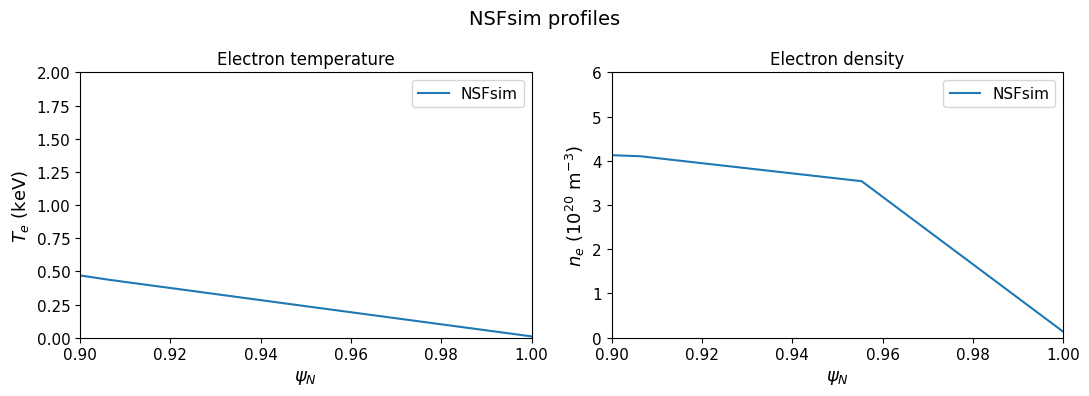

In [ ]:
PROF_PATH = Path('centaur_profiles.txt')
profiles = read_sparcpublic_profiles(PROF_PATH)
manual_profs = build_manual_profs(profiles)

_print_profile_summary("NSFsim", PROF_PATH, profiles)


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, qty, ylabel in zip(
    axes,
    ('Te', 'ne'),
    (r'$T_e$ (keV)', r'$n_e$ ($10^{20}$ m$^{-3}$)'),
):
    for label, prof, color in (
        ('NSFsim', profiles, 'C0'),
    ):
        psi_N, _ = psi_n_and_rho_psi(prof)
        y = prof[qty] if qty == 'Te' else prof[qty] / 1e20
        ax.plot(psi_N, y, '-', color=color, label=label)
    ax.set_xlabel(r'$\psi_N$', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=11)
    ax.set_xlim(0.9, 1)
axes[0].set_ylim(ymin=0, ymax=2.0)
axes[1].set_ylim(ymin=0, ymax=6.0)
axes[0].set_title('Electron temperature')
axes[1].set_title('Electron density')
fig.suptitle('NSFsim profiles', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Parameters for ESCAPE #

# Output directory
output_dir = 'logs'
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Scan parameters
x_res = 50
free_params = {
    'alpha_crit': 10,
    'C_KBM': 0.1,
    'De_chie_etg': 1,
    'nFC_x0': 1e15,
    'ncx_x0_ratio': 17.8
}
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
eped_tol_max = 1e-5
eped_iter_max = 5
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

verbose_EPEDNNloop = True
verbose_sc = False

Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
------------------------------------------------
ESCAPE Loop Iter 0
betan: [1.01631193]
Pedestal height: 0.023834058006553607 MPa, Pedestal width: 0.008163018767268156 (psi_N)
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 1
betan: [0.72194011]
Pedestal height: 0.037508260316193476 MPa, Pedestal width: 0.010351941114319063 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.8418763955810686


┌ Warning: Extrapolation warning on bt=10.878258003764763 is above bound of 7.999000072479248
└ @ EPEDNN ~/simulator/plasma-limits/src/pedestal_prediction/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=10.878258003764763 is above bound of 7.999000072479248
└ @ EPEDNN ~/simulator/plasma-limits/src/pedestal_prediction/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 2
betan: [0.72164213]
Pedestal height: 0.030790367382131353 MPa, Pedestal width: 0.009166744438087704 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.29359464316121786
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 3
betan: [0.72072387]
Pedestal height: 0.035073310968564725 MPa, Pedestal width: 0.010017619471208484 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.23192205650874104


┌ Warning: Extrapolation warning on bt=10.878258003764763 is above bound of 7.999000072479248
└ @ EPEDNN ~/simulator/plasma-limits/src/pedestal_prediction/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=10.878258003764763 is above bound of 7.999000072479248
└ @ EPEDNN ~/simulator/plasma-limits/src/pedestal_prediction/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 4
betan: [0.71973722]
Pedestal height: 0.032502278539995676 MPa, Pedestal width: 0.009506726882750848 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.12430392639251162
Setting up EPEDNN...


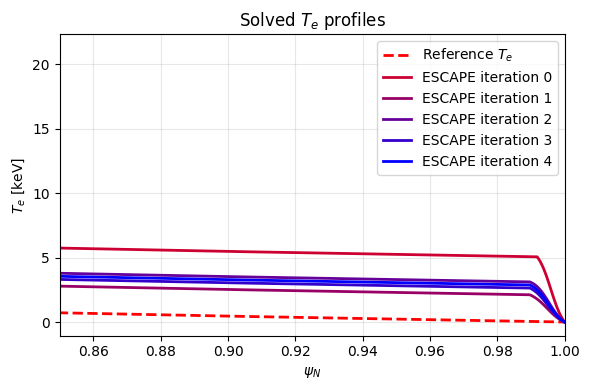

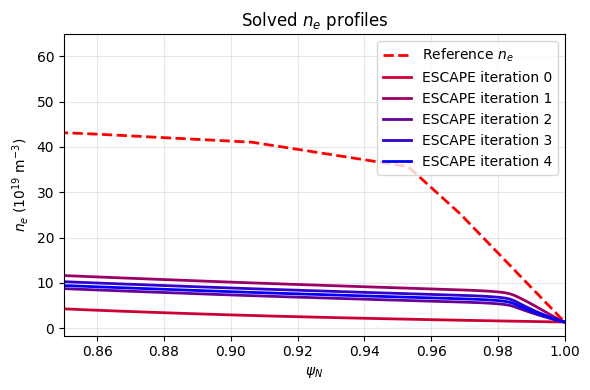

┌ Warning: Extrapolation warning on bt=10.878258003764763 is above bound of 7.999000072479248
└ @ EPEDNN ~/simulator/plasma-limits/src/pedestal_prediction/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


In [20]:
# ESCAPE run

# Note, if this is the first time running this cell, it may need to be run twice if the kernel fails (the first time to set up EPEDNN)
mhd_fp = "centaur.geqdsk"
P_tot_e = 10.0e6
ped_wid, ped_h_out, _ = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual rho grid',
    manual_profs = manual_profs,
    P_tot_e = P_tot_e,
    species = 'D-T',
    Z_i = np.mean(Zeff),
    out_dir = output_dir,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_max_it = picard_max_it,
    picard_rtol = picard_rtol,
    picard_relax = picard_relax,
    ig = 'manual',
    epednn_model = epednn_model,
    verbose = verbose_EPEDNNloop,
    verbose_sc = verbose_sc,
)


In [ ]:
# Profile pressure at the EPEDNN-predicted pedestal top (psi_N = 1 - ped_wid)
psi_N_p, p_Pa, p_mode = calc_pressure_profile(profiles)
psi_ped_top = 1.0 - float(ped_wid)
p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

print(f'Pressure formula: {p_mode}')
print(f'EPEDNN ped_top at psi_N = 1 - ped_wid = {psi_ped_top:.6f}')
print(f'Profile p(psi_ped_top) = {p_at_ped_top/1e3:.3f} kPa  ({p_at_ped_top/1e6:.4f} MPa)')
print(f'EPEDNN ped_h_out       = {float(ped_h_out)*1e3:.3f} kPa  ({float(ped_h_out):.4f} MPa)')
print(f'Accuracy of EPEDNN pedestal height prediction: {100*(float(p_at_ped_top/1e6) - float(ped_h_out))/float(ped_h_out):.2f}%')

Pressure formula: ne*Te + ne*Ti (ni=ne)
EPEDNN ped_top at psi_N = 1 - ped_wid = 0.990493
Profile p(psi_ped_top) = 5.020 kPa  (0.0050 MPa)
EPEDNN ped_h_out       = 32.502 kPa  (0.0325 MPa)
Accuracy of EPEDNN pedestal height prediction: -84.55%


In [23]:
# Save model output
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ESCAPE_ped_h': ped_h_out,
    'ESCAPE_ped_wid': ped_wid,
    'experimental_ped_h': p_at_ped_top,
}
np.save(output_dir+'/pedestal_prediction.npy', out_dict)